In [1]:
# 气候数据可视化复现
# 复现以下图表：
# 1. 01_global_temperature_trend.png - 全球温度趋势
# 2. 01_temperature_bands.png - 温度带图
# 3. 02_country_heatmap_pro.png - 国家热力图
# 4. 06_temperature_change_rate.png - 温度变化速率
# 5. 04_latitude_violin.png - 纬度小提琴图
# 6. 05_temperature_distribution.png - 温度分布
# 7. 12_decade_comparison.png - 年代对比

# 在notebook中显示图表
%matplotlib inline

import sys
import os
sys.path.append('../code')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

# 设置中文字体
MAC_CHINESE_FONTS = ['STHeiti', 'PingFang SC', 'Hiragino Sans GB', 'Arial Unicode MS']
plt.rcParams['font.sans-serif'] = MAC_CHINESE_FONTS + ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

# 设置Seaborn风格
sns.set_theme(style="ticks", context="talk")

# 数据路径
DATA_DIR = Path('../data/raw')
OUTPUT_DIR = Path('../output/notebook_figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 是否保存图片（设为False时只显示不保存）
SAVE_FIGURES = False

print("✓ 环境设置完成")
print(f"✓ 数据目录: {DATA_DIR}")
print(f"✓ 输出目录: {OUTPUT_DIR}")
print(f"✓ 保存图片: {'是' if SAVE_FIGURES else '否（仅显示）'}")


✓ 环境设置完成
✓ 数据目录: ../data/raw
✓ 输出目录: ../output/notebook_figures
✓ 保存图片: 否（仅显示）


In [2]:
# 加载数据
from data_loader import ClimateDataLoader

loader = ClimateDataLoader(data_dir=str(DATA_DIR))

print("正在加载数据...")
df_global = loader.load_global_temperatures()
df_country = loader.load_country_temperatures()
df_city = loader.load_city_temperatures(major_cities_only=True)

print("\n✓ 数据加载完成")
print(f"  全球温度: {len(df_global):,} 条记录")
print(f"  国家温度: {len(df_country):,} 条记录")
print(f"  城市温度: {len(df_city):,} 条记录")


正在加载数据...
正在加载全球温度数据: ../data/raw/GlobalTemperatures.csv
✓ 加载完成：3192 条记录
正在加载国家温度数据: ../data/raw/GlobalLandTemperaturesByCountry.csv
✓ 加载完成：577462 条记录
  国家数量: 243
正在加载主要城市温度数据: ../data/raw/GlobalLandTemperaturesByMajorCity.csv
✓ 加载完成：239177 条记录
  城市数量: 100
  国家数量: 49

✓ 数据加载完成
  全球温度: 3,192 条记录
  国家温度: 577,462 条记录
  城市温度: 239,177 条记录


📊 绘制图1: 全球温度趋势...


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/3858433686.py:42: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/3858433686.py:42: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/3858433686.py:42: UserWarning: Glyph 38470 (\N{CJK UNIFIED IDEOGRAPH-9646}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/3858433686.py:42: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/3858433686.py:42: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/i

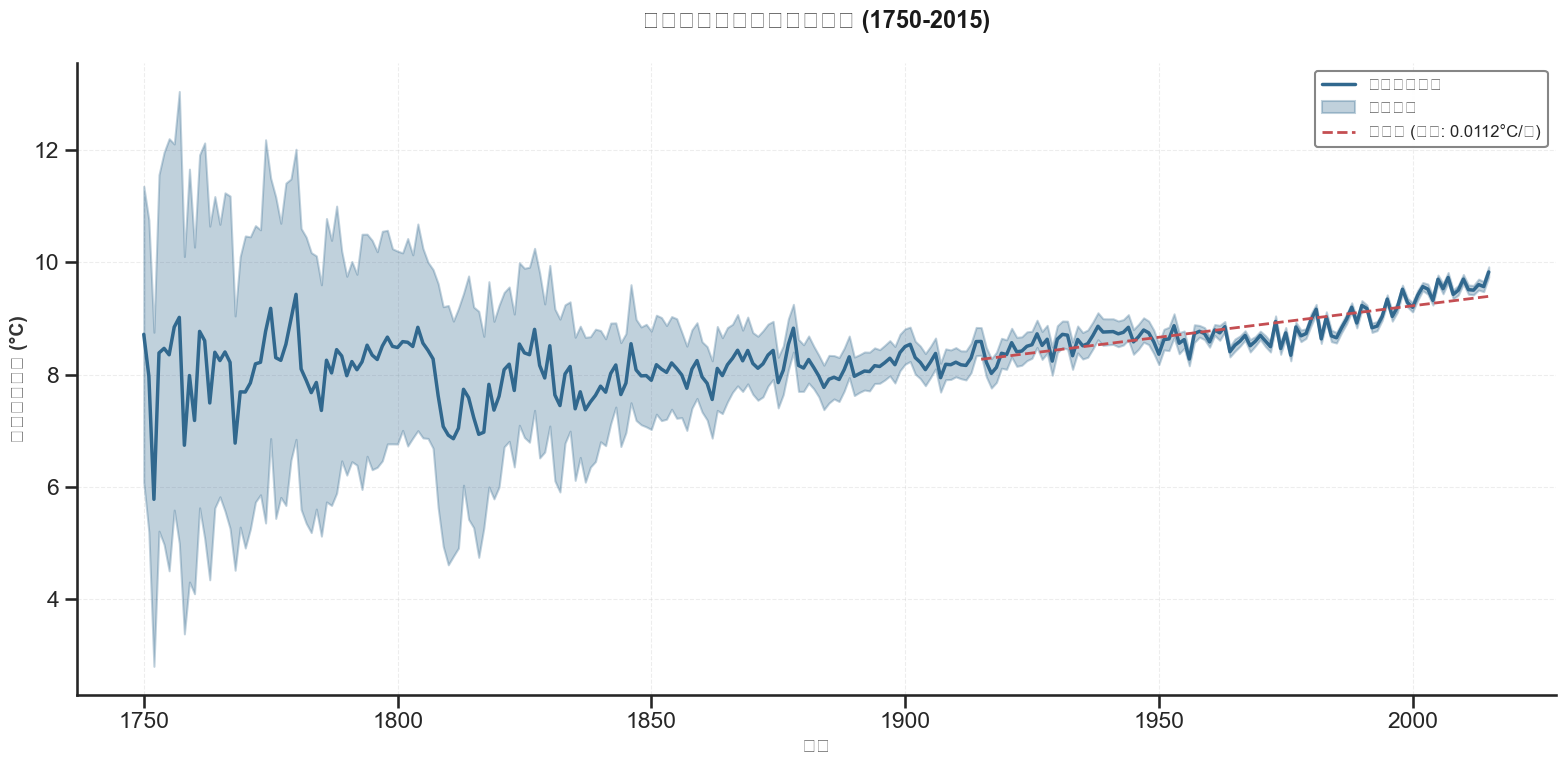

✓ 图表已显示（未保存）


In [3]:
# 图1: 全球温度趋势 (01_global_temperature_trend.png)
print("📊 绘制图1: 全球温度趋势...")

# 按年份聚合
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index()
df_yearly = df_yearly.dropna()

fig, ax = plt.subplots(figsize=(16, 8))

# 绘制主线
viridis_colors = sns.color_palette("viridis", 2)
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
       linewidth=2.5, color=viridis_colors[0], label='陆地平均温度')

# 绘制置信区间
ax.fill_between(
    df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.3, color=viridis_colors[0], label='置信区间'
)

# 添加趋势线（最近100年）
recent_df = df_yearly[df_yearly['year'] >= df_yearly['year'].max() - 100]
z = np.polyfit(recent_df['year'], recent_df['LandAverageTemperature'], 1)
p = np.poly1d(z)
ax.plot(recent_df['year'], p(recent_df['year']), 
       'r--', linewidth=2, label=f'趋势线 (斜率: {z[0]:.4f}°C/年)')

ax.set_xlabel('年份', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('陆地平均温度 (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('全球陆地平均温度变化趋势 (1750-2015)', 
            fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '01_global_temperature_trend.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 01_global_temperature_trend.png")
else:
    print("✓ 图表已显示（未保存）")


📊 绘制图2: 温度带图...


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2458810729.py:55: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2458810729.py:55: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2458810729.py:55: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2458810729.py:55: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2458810729.py:55: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/i

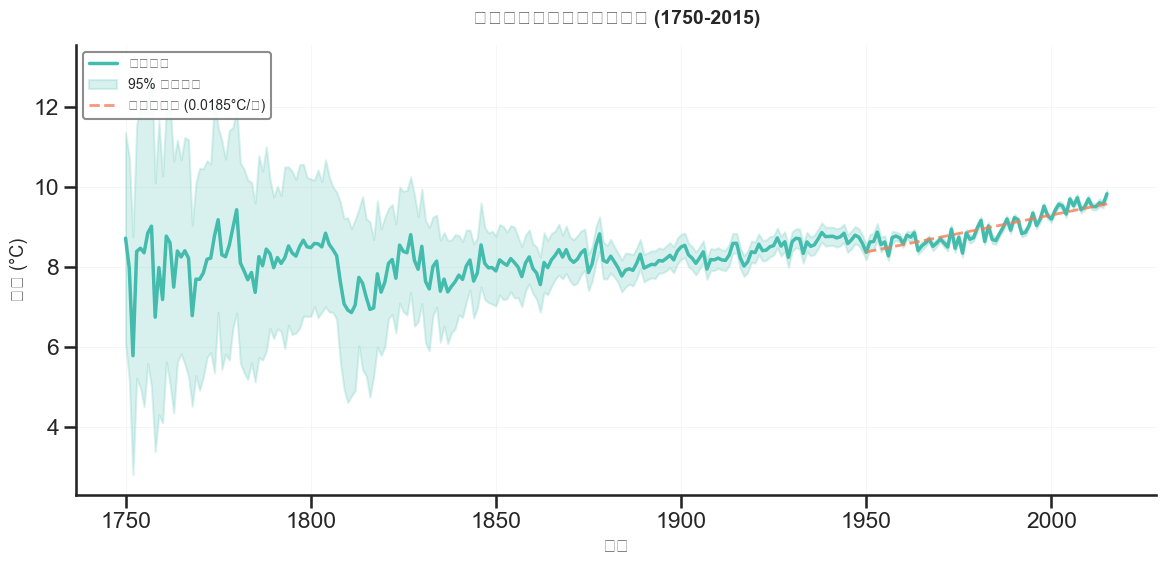

✓ 图表已显示（未保存）


In [4]:
# 图2: 温度带图 (01_temperature_bands.png)
print("📊 绘制图2: 温度带图...")

# 数据准备
df_yearly = df_global.groupby('year').agg({
    'LandAverageTemperature': 'mean',
    'LandAverageTemperatureUncertainty': 'mean'
}).reset_index().dropna()

# 创建图表
fig, ax = plt.subplots(figsize=(12, 6))

# 配色方案
COLORS = {
    'mako': sns.color_palette("mako", n_colors=10),
    'rocket': sns.color_palette("rocket", n_colors=10),
}

# 主线 - 使用 mako 深色
ax.plot(df_yearly['year'], df_yearly['LandAverageTemperature'],
       linewidth=2.5, color=COLORS['mako'][7], label='全球温度', zorder=3)

# 置信带 - 半透明
ax.fill_between(
    df_yearly['year'],
    df_yearly['LandAverageTemperature'] - df_yearly['LandAverageTemperatureUncertainty'],
    df_yearly['LandAverageTemperature'] + df_yearly['LandAverageTemperatureUncertainty'],
    alpha=0.2, color=COLORS['mako'][7], label='95% 置信区间', zorder=2
)

# 趋势线（1950后）- 使用 rocket 亮色
recent = df_yearly[df_yearly['year'] >= 1950]
z = np.polyfit(recent['year'], recent['LandAverageTemperature'], 1)
p = np.poly1d(z)
ax.plot(recent['year'], p(recent['year']), 
       linestyle='--', linewidth=2, color=COLORS['rocket'][7],
       label=f'加速期趋势 ({z[0]:.4f}°C/年)', alpha=0.8, zorder=3)

# 样式设置
ax.set_xlabel('年份', fontsize=13, weight='medium')
ax.set_ylabel('温度 (°C)', fontsize=13, weight='medium')
ax.set_title('全球陆地平均温度长期趋势 (1750-2015)', 
            fontsize=14, weight='bold', pad=15)

# 图例
ax.legend(loc='upper left', fontsize=10, frameon=True, 
         framealpha=0.9, edgecolor='gray', facecolor='white')

# 网格
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)

# 去掉上右边框
sns.despine()

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '01_temperature_bands.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 01_temperature_bands.png")
else:
    print("✓ 图表已显示（未保存）")


📊 绘制图3: 国家温度热力图...


/Users/haoyin/Documents/大三上/数据可视化/Final/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/haoyin/Documents/大三上/数据可视化/Final/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/haoyin/Documents/大三上/数据可视化/Final/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/haoyin/Documents/大三上/数据可视化/Final/venv/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  fig.canvas.draw()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/882189055.py:46: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
/var/folder

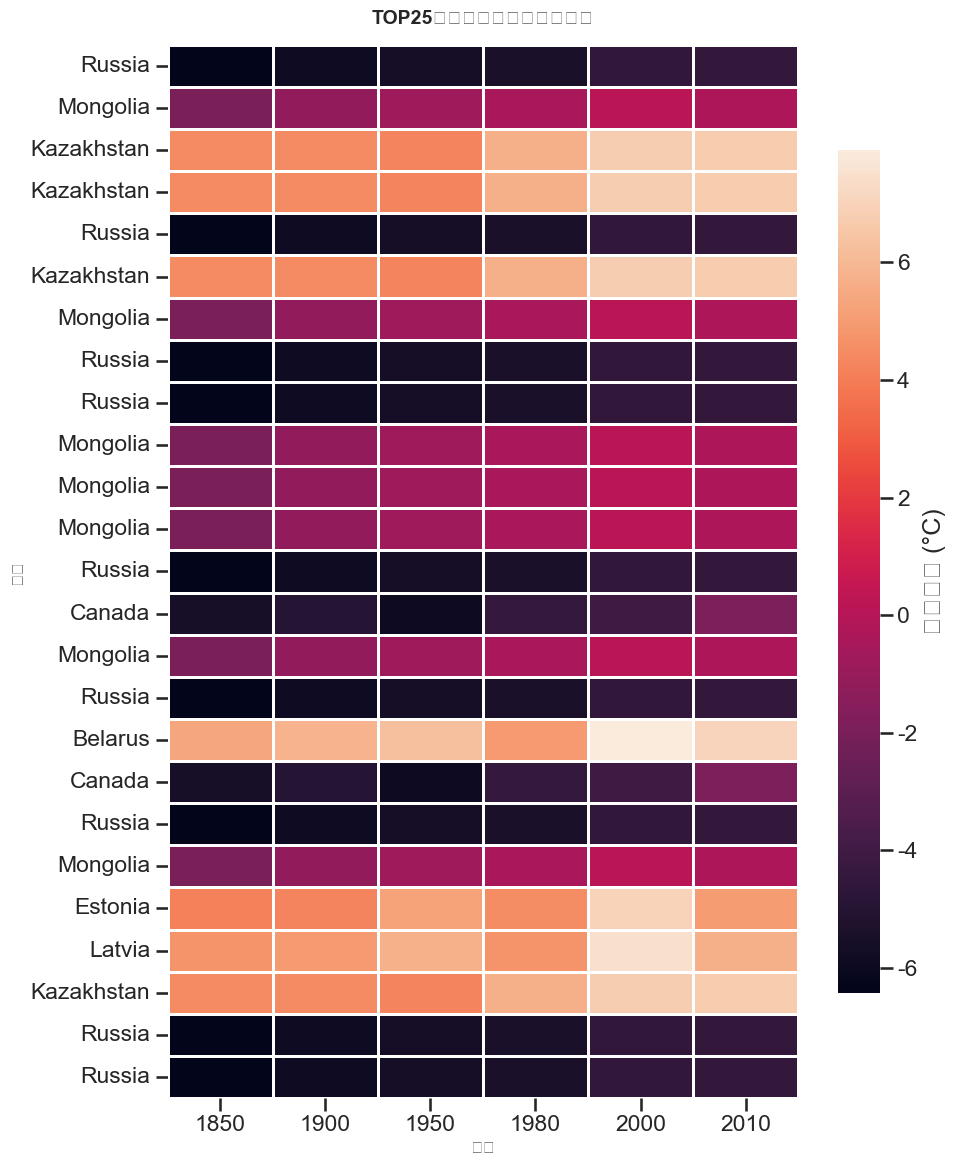

✓ 图表已显示（未保存）


In [5]:
# 图3: 国家热力图 (02_country_heatmap_pro.png)
print("📊 绘制图3: 国家温度热力图...")

# 选择TOP25变化最大的国家
key_years = [1850, 1900, 1950, 1980, 2000, 2010]

df_2010 = df_country[df_country['year'] == 2010].copy()
df_1850 = df_country[df_country['year'] == 1850].copy()
df_change = df_2010.merge(df_1850, on='Country', suffixes=('_2010', '_1850'))
df_change['temp_change'] = (df_change['AverageTemperature_2010'] - 
                            df_change['AverageTemperature_1850'])
top_countries = df_change.nlargest(25, 'temp_change')['Country'].tolist()

# 准备数据
heatmap_data = []
for country in top_countries:
    temps = []
    for year in key_years:
        df_filtered = df_country[(df_country['Country'] == country) & 
                                (df_country['year'] == year)]
        if not df_filtered.empty:
            temps.append(df_filtered['AverageTemperature'].mean())
        else:
            temps.append(np.nan)
    heatmap_data.append(temps)

heatmap_df = pd.DataFrame(heatmap_data, index=top_countries, columns=key_years)

# 绘制
fig, ax = plt.subplots(figsize=(10, 12))

# 使用 rocket 配色，调整 vmin/vmax 让对比度更明显
data_min = heatmap_df.min().min()
data_max = heatmap_df.max().max()

sns.heatmap(heatmap_df, cmap='rocket', annot=False,
           linewidths=1, linecolor='white', 
           cbar_kws={'label': '平均温度 (°C)', 'shrink': 0.8},
           ax=ax, vmin=data_min, vmax=data_max, robust=True)

ax.set_xlabel('年份', fontsize=12, weight='medium')
ax.set_ylabel('国家', fontsize=12, weight='medium')
ax.set_title('TOP25升温最快国家的温度演变', 
            fontsize=14, weight='bold', pad=15)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '02_country_heatmap_pro.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 02_country_heatmap_pro.png")
else:
    print("✓ 图表已显示（未保存）")


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/952787464.py:60: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/952787464.py:60: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/952787464.py:60: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/952787464.py:60: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/952787464.py:60: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipyker

📊 绘制图4: 温度变化速率...


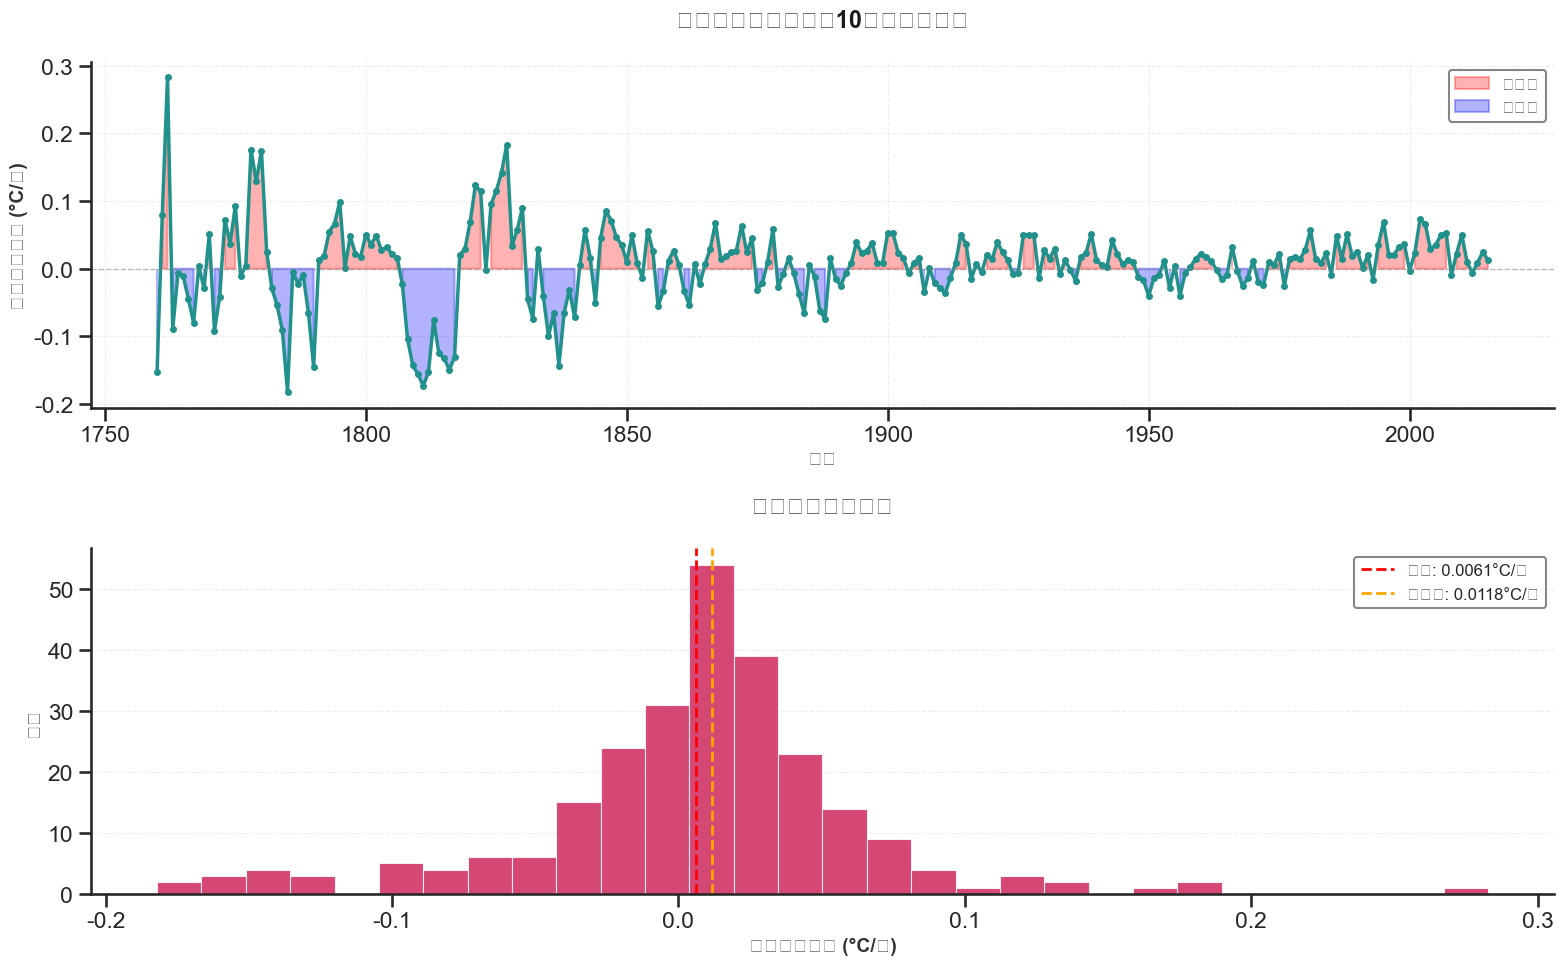

✓ 图表已显示（未保存）


In [6]:
# 图4: 温度变化速率 (06_temperature_change_rate.png)
print("📊 绘制图4: 温度变化速率...")

# 按10年窗口计算温度变化速率
df_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
df_yearly = df_yearly.dropna()

# 计算每10年的变化速率
window = 10
change_rates = []
years = []

for i in range(window, len(df_yearly)):
    start_temp = df_yearly.iloc[i-window]['LandAverageTemperature']
    end_temp = df_yearly.iloc[i]['LandAverageTemperature']
    start_year = df_yearly.iloc[i-window]['year']
    end_year = df_yearly.iloc[i]['year']
    
    rate = (end_temp - start_temp) / window  # °C/年
    change_rates.append(rate)
    years.append(end_year)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# 子图1：变化速率时间序列
viridis_colors = sns.color_palette("viridis", 1)
ax1.plot(years, change_rates, linewidth=2.5, color=viridis_colors[0], marker='o', markersize=4)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.fill_between(years, 0, change_rates, where=np.array(change_rates) > 0, 
                alpha=0.3, color='red', label='升温期')
ax1.fill_between(years, 0, change_rates, where=np.array(change_rates) < 0, 
                alpha=0.3, color='blue', label='降温期')

ax1.set_xlabel('年份', fontsize=14, fontweight='bold', color='#333333')
ax1.set_ylabel('温度变化速率 (°C/年)', fontsize=14, fontweight='bold', color='#333333')
ax1.set_title('全球温度变化速率（10年滑动窗口）', 
             fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax1.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax1.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 子图2：变化速率分布直方图
rocket_colors = sns.color_palette("rocket_r", 1)
ax2.hist(change_rates, bins=30, color=rocket_colors[0], edgecolor='white', 
        linewidth=0.8, alpha=0.8)
ax2.axvline(np.mean(change_rates), color='red', linestyle='--', linewidth=2,
           label=f'均值: {np.mean(change_rates):.4f}°C/年')
ax2.axvline(np.median(change_rates), color='orange', linestyle='--', linewidth=2,
           label=f'中位数: {np.median(change_rates):.4f}°C/年')

ax2.set_xlabel('温度变化速率 (°C/年)', fontsize=14, fontweight='bold', color='#333333')
ax2.set_ylabel('频次', fontsize=14, fontweight='bold', color='#333333')
ax2.set_title('温度变化速率分布', fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax2.legend(fontsize=12, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax2.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '06_temperature_change_rate.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 06_temperature_change_rate.png")
else:
    print("✓ 图表已显示（未保存）")


📊 绘制图5: 纬度带温度分布小提琴图...


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2847649129.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_recent, x='latitude_band', y='AverageTemperature',
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2847649129.py:38: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.violinplot(data=df_recent, x='latitude_band', y='AverageTemperature',
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2847649129.py:58: UserWarning: Glyph 32428 (\N{CJK UNIFIED IDEOGRAPH-7EAC}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/2847649129.py:58: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  

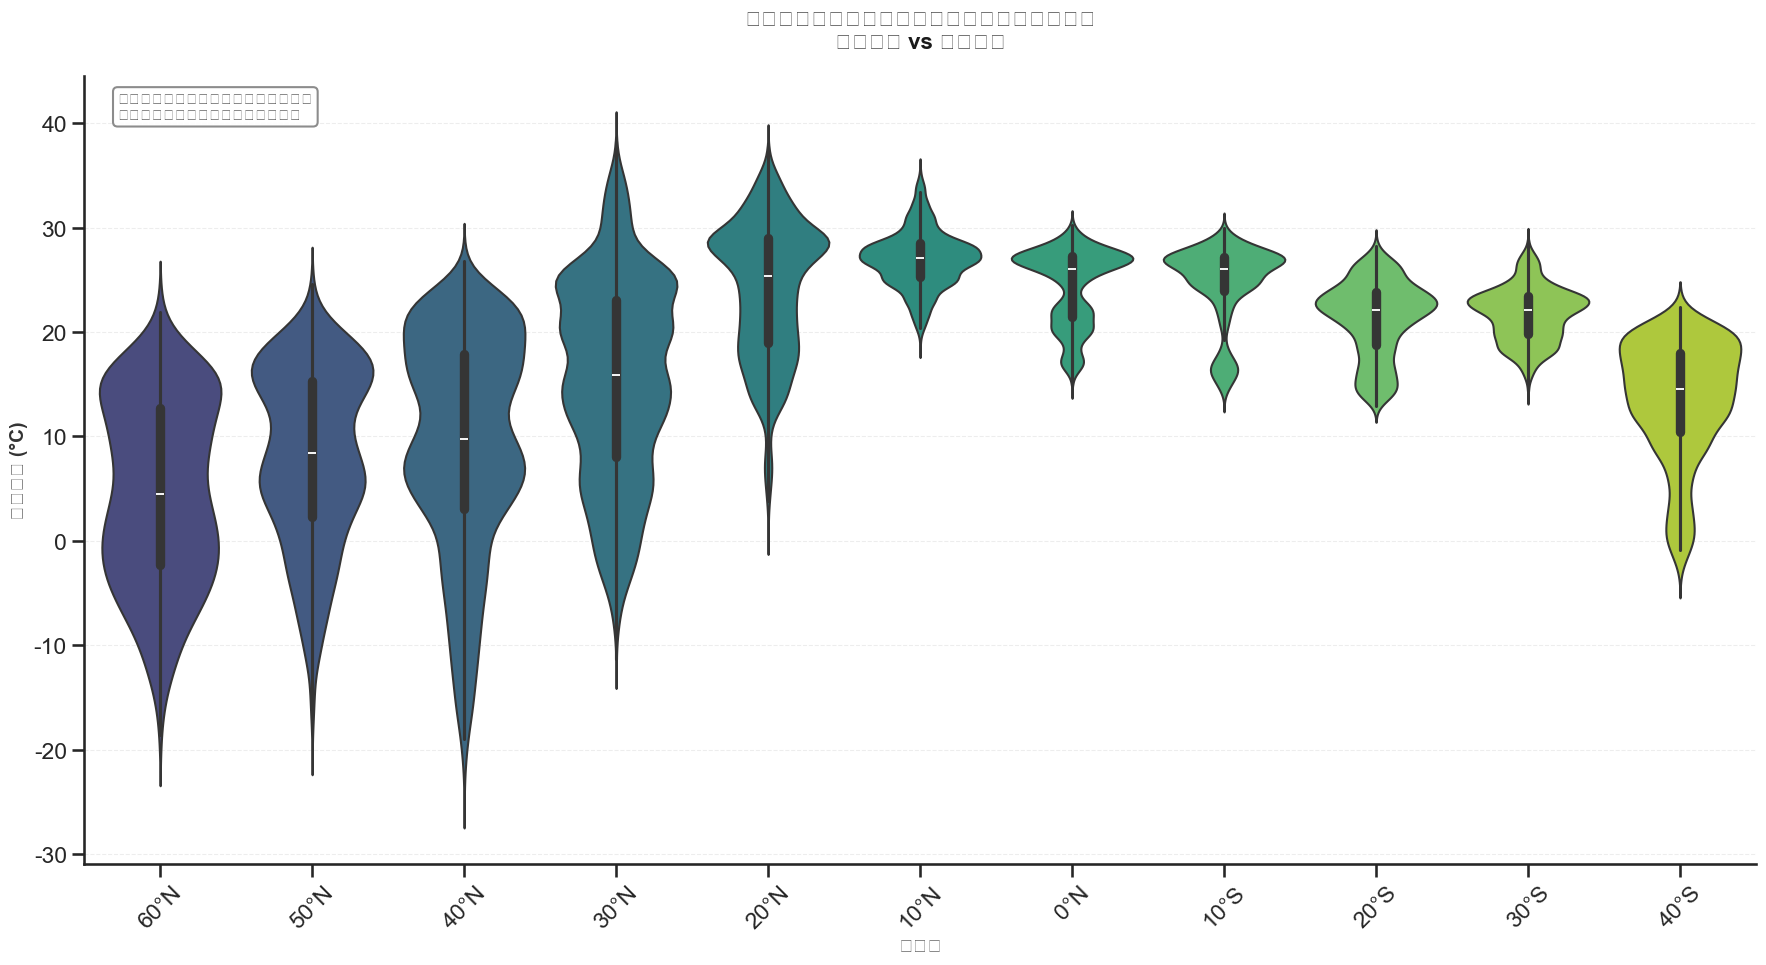

✓ 图表已显示（未保存）


In [7]:
# 图5: 纬度小提琴图 (04_latitude_violin.png)
print("📊 绘制图5: 纬度带温度分布小提琴图...")

# 过滤最近50年的数据
df_recent = df_city[df_city['year'] >= df_city['year'].max() - 50].copy()

# 创建纬度带（每10度一个区间）
def assign_latitude_band(lat):
    if pd.isna(lat):
        return None
    lat_rounded = int(lat // 10) * 10
    if lat >= 0:
        return f"{lat_rounded}°N"
    else:
        return f"{-lat_rounded}°S"

df_recent['latitude_band'] = df_recent['Latitude_num'].apply(assign_latitude_band)
df_recent = df_recent.dropna(subset=['latitude_band', 'AverageTemperature'])

# 按纬度排序
def parse_latitude_for_sort(lat_str):
    """解析纬度字符串用于排序"""
    if '°N' in lat_str:
        return float(lat_str.replace('°N', ''))
    elif '°S' in lat_str:
        return -float(lat_str.replace('°S', ''))
    return 0

latitude_order = sorted(df_recent['latitude_band'].unique(), 
                       key=parse_latitude_for_sort, 
                       reverse=True)

fig, ax = plt.subplots(figsize=(18, 10))

# 绘制小提琴图（使用 viridis 渐变）
viridis_cmap = sns.color_palette("viridis", as_cmap=True)
violin_colors = viridis_cmap(np.linspace(0.2, 0.9, len(latitude_order)))
sns.violinplot(data=df_recent, x='latitude_band', y='AverageTemperature',
              order=latitude_order, palette=violin_colors,
              inner='box', linewidth=1.5, ax=ax)

ax.set_xlabel('纬度带', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('平均温度 (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('第三章：纬度带温度分布形态差异（小提琴图）\n高纬双峰 vs 低纬稳定',
            fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax.tick_params(axis='x', rotation=45)

# 添加注释
ax.text(0.02, 0.98, '高纬度区：双峰结构（冬夏巨大差异）\n低纬度区：窄高分布（全年温差小）', 
       transform=ax.transAxes, fontsize=11, va='top', ha='left',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# 美化
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '04_latitude_violin.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 04_latitude_violin.png")
else:
    print("✓ 图表已显示（未保存）")


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_selected, x='Country', y='AverageTemperature',
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 22269 (\N{CJK UNIFIED IDEOGRAPH-56FD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()


📊 绘制图6: 温度分布箱线图...


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/1216006347.py:28: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/i

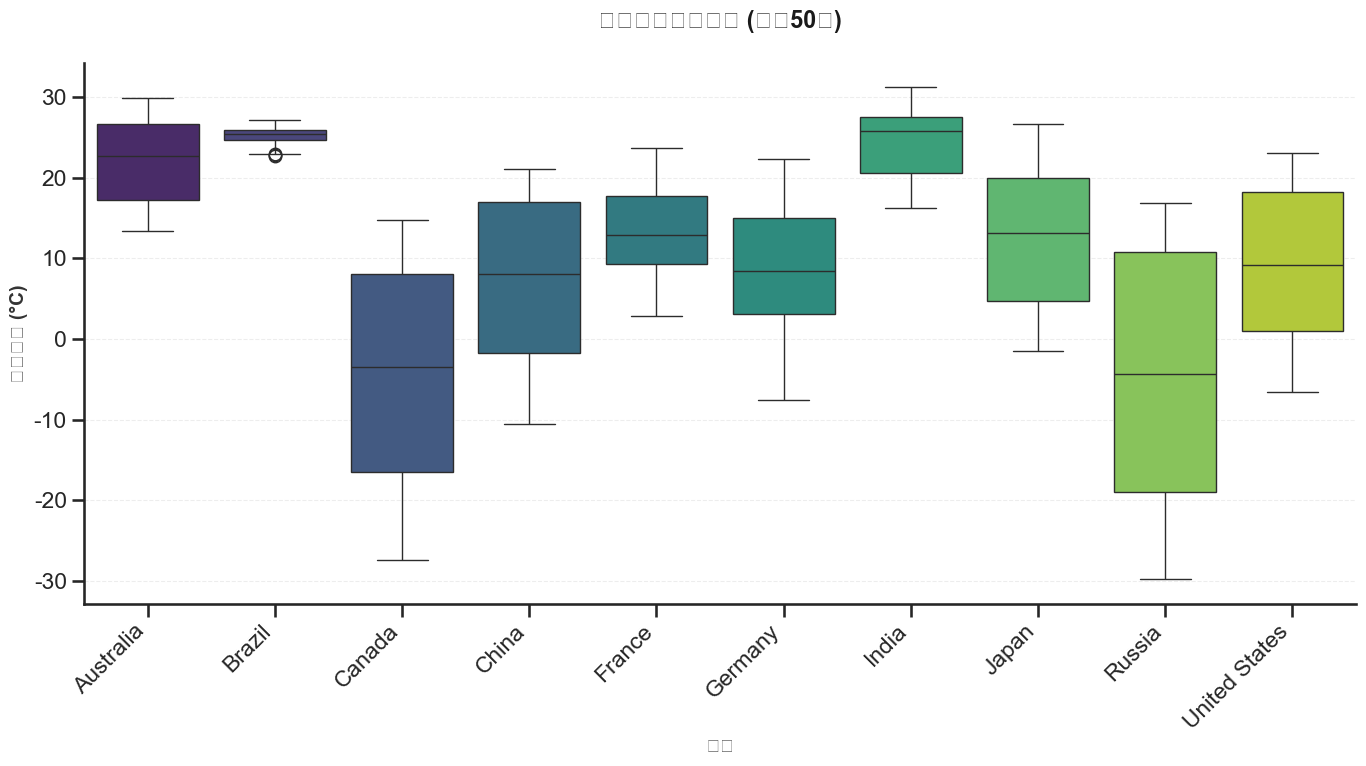

✓ 图表已显示（未保存）


In [8]:
# 图6: 温度分布箱线图 (05_temperature_distribution.png)
print("📊 绘制图6: 温度分布箱线图...")

# 选择部分国家
countries = ['China', 'United States', 'Russia', 'India', 'Brazil', 
            'Canada', 'Australia', 'Germany', 'France', 'Japan']
df_selected = df_country[df_country['Country'].isin(countries)]

# 只使用最近50年数据
max_year = df_selected['year'].max()
df_selected = df_selected[df_selected['year'] >= max_year - 50]

fig, ax = plt.subplots(figsize=(14, 8))

viridis_palette = sns.color_palette("viridis", len(countries))
sns.boxplot(data=df_selected, x='Country', y='AverageTemperature',
           palette=viridis_palette, ax=ax)

ax.set_xlabel('国家', fontsize=14, fontweight='bold', color='#333333')
ax.set_ylabel('平均温度 (°C)', fontsize=14, fontweight='bold', color='#333333')
ax.set_title('主要国家温度分布 (最近50年)', 
            fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')
ax.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '05_temperature_distribution.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 05_temperature_distribution.png")
else:
    print("✓ 图表已显示（未保存）")


📊 绘制图7: 年代对比分析...


/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/551368233.py:85: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/551368233.py:85: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/551368233.py:85: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/551368233.py:85: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipykernel_85431/551368233.py:85: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/j8/x_rv5w7x193g_dg9zr7nm6040000gn/T/ipyker

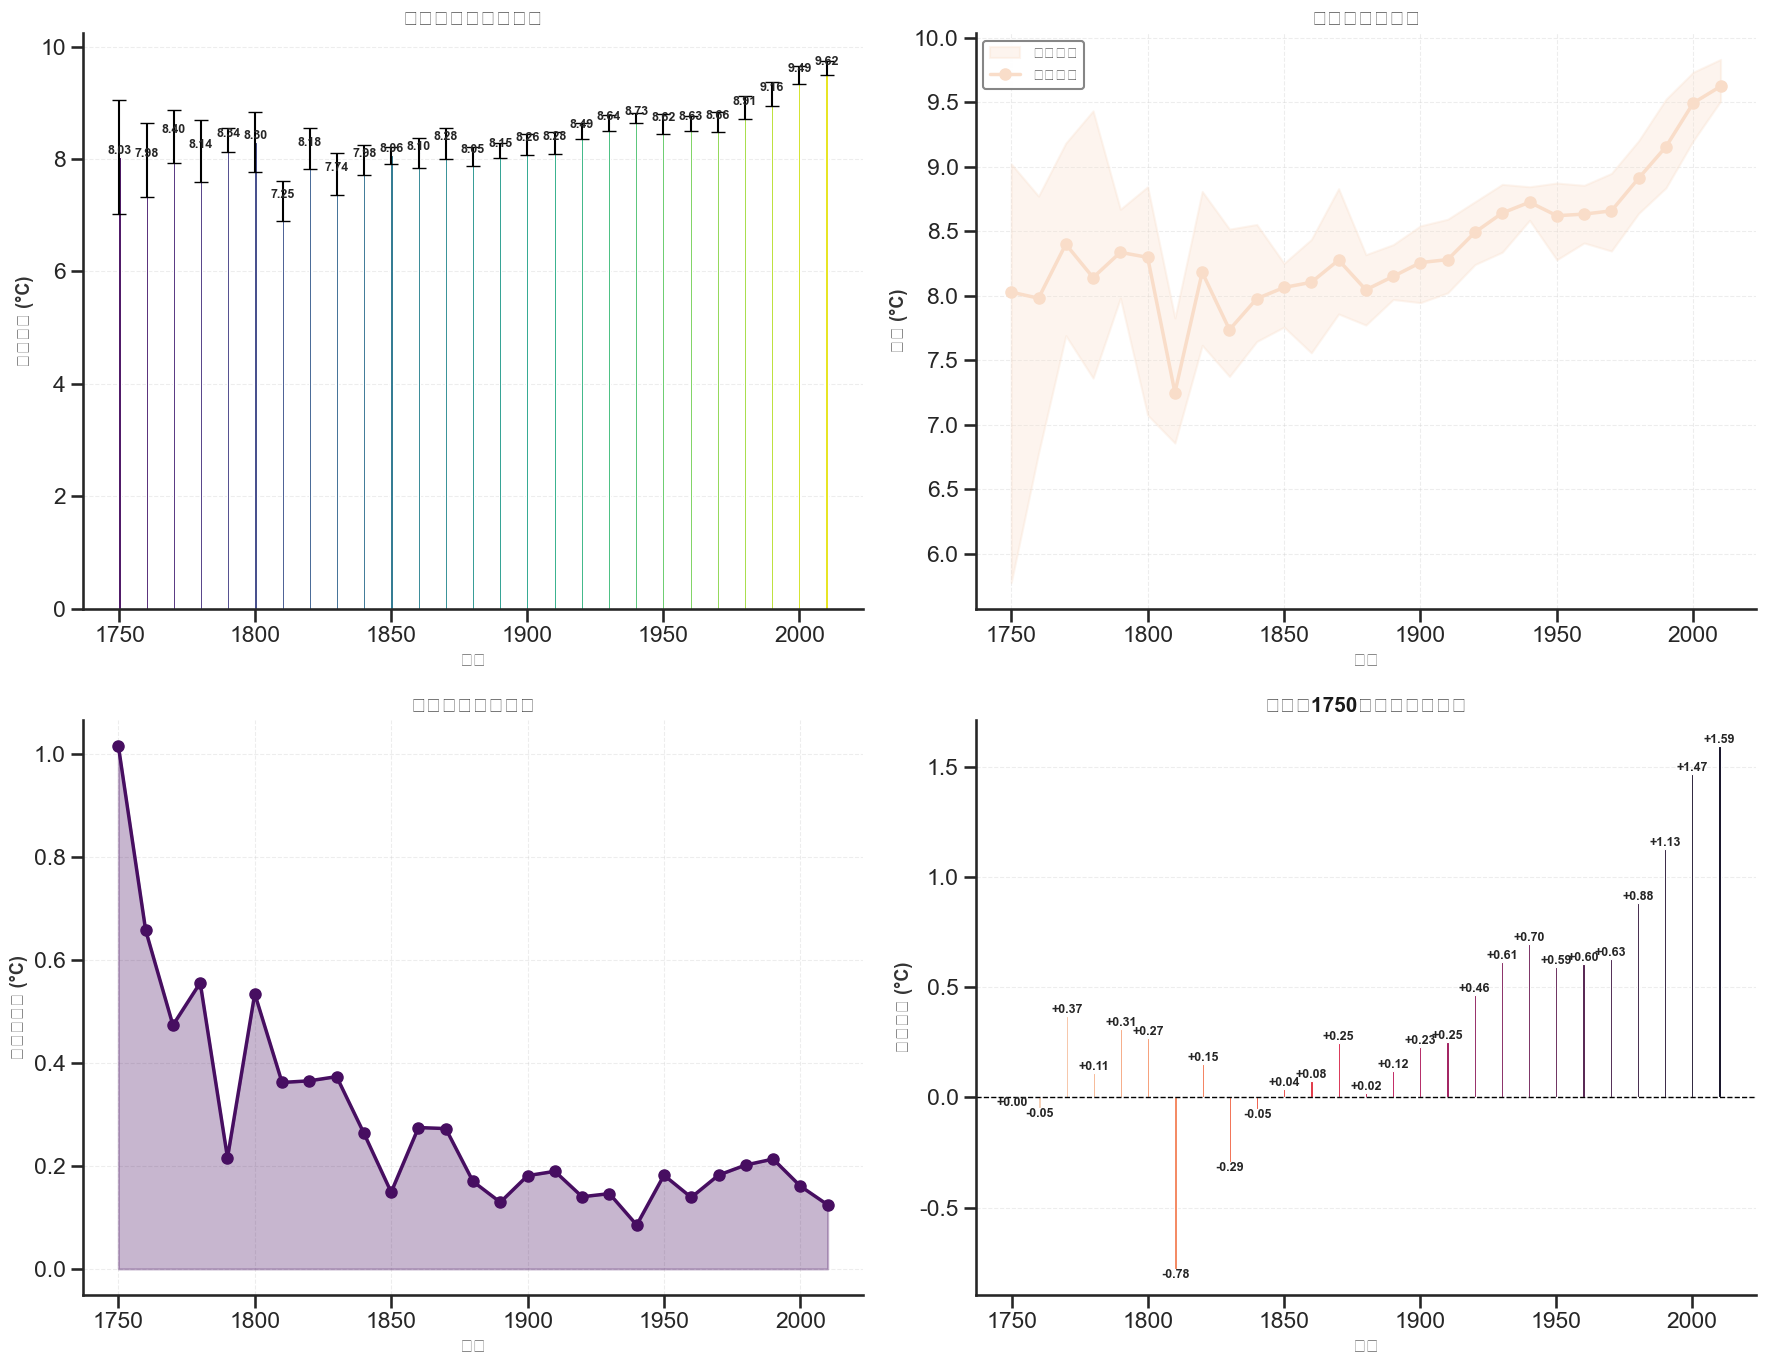

✓ 图表已显示（未保存）


In [9]:
# 图7: 年代对比分析 (12_decade_comparison.png)
print("📊 绘制图7: 年代对比分析...")

# 按年份聚合
df_yearly = df_global.groupby('year')['LandAverageTemperature'].mean().reset_index()
df_yearly = df_yearly.dropna()

# 按年代分组
df_yearly['decade'] = (df_yearly['year'] // 10) * 10
df_decade = df_yearly.groupby('decade')['LandAverageTemperature'].agg(['mean', 'std', 'min', 'max']).reset_index()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 14))

# 子图1：年代平均温度
viridis_colors = sns.color_palette("viridis", len(df_decade))
bars1 = ax1.bar(df_decade['decade'], df_decade['mean'],
               color=viridis_colors, edgecolor='white', linewidth=0.8)
ax1.errorbar(df_decade['decade'], df_decade['mean'], yerr=df_decade['std'],
             fmt='none', color='black', capsize=5, linewidth=1.5)

ax1.set_xlabel('年代', fontsize=13, fontweight='bold', color='#333333')
ax1.set_ylabel('平均温度 (°C)', fontsize=13, fontweight='bold', color='#333333')
ax1.set_title('各年代平均温度对比', fontsize=15, fontweight='bold', color='#1a1a1a')
ax1.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# 添加数值标签
for bar, mean_val in zip(bars1, df_decade['mean']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{mean_val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 子图2：温度范围（min-max）
rocket_colors = sns.color_palette("rocket_r", len(df_decade))
ax2.fill_between(df_decade['decade'], df_decade['min'], df_decade['max'],
                alpha=0.3, color=rocket_colors[0], label='温度范围')
ax2.plot(df_decade['decade'], df_decade['mean'], 'o-', linewidth=2.5,
        color=rocket_colors[0], markersize=8, label='平均温度')

ax2.set_xlabel('年代', fontsize=13, fontweight='bold', color='#333333')
ax2.set_ylabel('温度 (°C)', fontsize=13, fontweight='bold', color='#333333')
ax2.set_title('各年代温度范围', fontsize=15, fontweight='bold', color='#1a1a1a')
ax2.legend(fontsize=11, frameon=True, fancybox=True, framealpha=0.95, edgecolor='gray')
ax2.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 子图3：温度标准差（波动性）
ax3.plot(df_decade['decade'], df_decade['std'], 'o-', linewidth=2.5,
        color=viridis_colors[0], markersize=8)
ax3.fill_between(df_decade['decade'], 0, df_decade['std'],
                alpha=0.3, color=viridis_colors[0])

ax3.set_xlabel('年代', fontsize=13, fontweight='bold', color='#333333')
ax3.set_ylabel('温度标准差 (°C)', fontsize=13, fontweight='bold', color='#333333')
ax3.set_title('各年代温度波动性', fontsize=15, fontweight='bold', color='#1a1a1a')
ax3.grid(True, alpha=0.35, linestyle='--', linewidth=0.8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# 子图4：温度变化趋势（相对于第一个年代）
first_decade_temp = df_decade.iloc[0]['mean']
df_decade['change_from_first'] = df_decade['mean'] - first_decade_temp

bars4 = ax4.bar(df_decade['decade'], df_decade['change_from_first'],
               color=rocket_colors, edgecolor='white', linewidth=0.8)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)

ax4.set_xlabel('年代', fontsize=13, fontweight='bold', color='#333333')
ax4.set_ylabel('温度变化 (°C)', fontsize=13, fontweight='bold', color='#333333')
ax4.set_title(f'相对于{int(df_decade.iloc[0]["decade"])}年代的温度变化', 
             fontsize=15, fontweight='bold', color='#1a1a1a')
ax4.grid(axis='y', alpha=0.35, linestyle='--', linewidth=0.8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# 添加数值标签
for bar, change in zip(bars4, df_decade['change_from_first']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{change:+.2f}', ha='center', 
            va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=9)

plt.tight_layout()

# 显示图表
plt.show()

# 可选：保存图表
if SAVE_FIGURES:
    plt.savefig(OUTPUT_DIR / '12_decade_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ 已保存: 12_decade_comparison.png")
else:
    print("✓ 图表已显示（未保存）")


In [10]:
# 完成总结
print("\n" + "="*60)
print("✅ 所有图表复现完成！")
print("="*60)

if SAVE_FIGURES:
    print(f"\n📁 输出目录: {OUTPUT_DIR}")
    print("\n生成的图表:")
    print("  1. 01_global_temperature_trend.png - 全球温度趋势")
    print("  2. 01_temperature_bands.png - 温度带图")
    print("  3. 02_country_heatmap_pro.png - 国家热力图")
    print("  4. 06_temperature_change_rate.png - 温度变化速率")
    print("  5. 04_latitude_violin.png - 纬度小提琴图")
    print("  6. 05_temperature_distribution.png - 温度分布")
    print("  7. 12_decade_comparison.png - 年代对比")
else:
    print("\n💡 提示：所有图表已在notebook中显示")
    print("   如需保存，请将第一个cell中的 SAVE_FIGURES 设为 True")
    print("   然后重新运行相应的cell")

print("\n" + "="*60)



✅ 所有图表复现完成！

💡 提示：所有图表已在notebook中显示
   如需保存，请将第一个cell中的 SAVE_FIGURES 设为 True
   然后重新运行相应的cell

